# 🌌 Aurora Activity — Deep LSTM Prediction & Forecasting
**Models:** Stacked LSTM · Bidirectional LSTM · CNN-LSTM · Attention-LSTM

**Targets:** Kp Index · Ap Index · Daily Ap · Aurora Probability

**Features:** Kp1-Kp8 (3-hourly), ap1-ap8, Ap, SN (sunspot number), F10.7 solar flux

In [21]:
# ── Mount Google Drive ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted ✓


In [22]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install tensorflow scikit-learn matplotlib pandas numpy seaborn -q
!pip install scipy joblib tqdm -q

In [23]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, Conv1D, MaxPooling1D,
    Flatten, Input, Attention, GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Add, BatchNormalization, GRU, concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: False


## Configuration

In [24]:
# ── Global configuration ───────────────────────────────────────────────────────

# Data path — point to your folder
FILE_PATH = "/content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/5years.txt"

# Sequence / training config
LOOKBACK        = 7        # days of history for each sequence (3 months)
FORECAST_DAYS   = 10        # future days to predict
TEST_SPLIT      = 0.15      # 15% test set
VAL_SPLIT       = 0.15      # 15% validation set
EPOCHS          = 30
BATCH_SIZE      = 64
LEARNING_RATE   = 1e-3

# Aurora classification thresholds (Kp scale)
# Kp >= 5  → G1 geomagnetic storm (visible aurora at lat ~60°N)
# Kp >= 6  → G2 storm (visible ~55°N)
# Kp >= 7  → G3 storm (visible ~50°N)
AURORA_KP_THRESHOLD = 5.0

# Feature columns to use as model inputs
FEATURE_COLS = [
    'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',   # 3-hourly Kp
    'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',     # 3-hourly ap
    'Ap',                                                 # daily ap
    'SN',                                                 # sunspot number
    'F107obs',                                            # solar radio flux
    'Kp_mean', 'Kp_max', 'Kp_std',                       # engineered daily features
    'ap_mean', 'Ap_lag1', 'Ap_lag7', 'Ap_rolling7',
    'SN_rolling27', 'F107_rolling27',
    'solar_cycle_phase',
]

# Primary prediction target
TARGET_COL = 'Kp_mean'  # daily mean Kp — proxy for aurora intensity

COLORS = {
    'Stacked LSTM':  '#3b82f6',
    'BiLSTM':        '#10b981',
    'CNN-LSTM':      '#f59e0b',
    'Attn-LSTM':     '#8b5cf6',
    'Actual':        '#1e293b',
    'Forecast':      '#ef4444',
}

In [25]:
# ── Output directories ─────────────────────────────────────────────────────────
# Save all outputs in a 'kp outputs' folder next to the data file
_base_dir = Path(FILE_PATH).parent
OUTPUT_DIR       = _base_dir / 'kp outputs'
OUTPUT_GRAPHS    = OUTPUT_DIR / 'graphs'
OUTPUT_DATA      = OUTPUT_DIR / 'data'

OUTPUT_GRAPHS.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

print(f'Output directory : {OUTPUT_DIR}')
print(f'Graphs subfolder : {OUTPUT_GRAPHS}')
print(f'Data subfolder   : {OUTPUT_DATA}')


Output directory : /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs
Graphs subfolder : /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/graphs
Data subfolder   : /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/data


## Data Loading & Parsing

In [26]:
def parse_kp_file(filepath):
    """
    Parse GFZ Kp/ap/Ap/SN/F10.7 fixed-width data files.
    Handles both the old and new GFZ format (post-2018 extended columns).
    Returns a clean daily DataFrame.
    """
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 28:
                continue
            try:
                year, month, day = int(parts[0]), int(parts[1]), int(parts[2])
                kp = [float(parts[7+i]) for i in range(8)]   # Kp1..Kp8
                ap = [int(parts[15+i]) for i in range(8)]    # ap1..ap8
                Ap = int(parts[23])
                SN = int(parts[24])
                f107obs = float(parts[25])
                f107adj = float(parts[26])
                rows.append({
                    'date': datetime(year, month, day),
                    'Kp1': kp[0],'Kp2': kp[1],'Kp3': kp[2],'Kp4': kp[3],
                    'Kp5': kp[4],'Kp6': kp[5],'Kp7': kp[6],'Kp8': kp[7],
                    'ap1': ap[0],'ap2': ap[1],'ap3': ap[2],'ap4': ap[3],
                    'ap5': ap[4],'ap6': ap[5],'ap7': ap[6],'ap8': ap[7],
                    'Ap': Ap, 'SN': SN,
                    'F107obs': f107obs, 'F107adj': f107adj
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)


def load_data(file_path):
    """
    Load a single GFZ Kp/ap/Ap/SN/F10.7 data file.
    """
    fp = Path(file_path)
    if not fp.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    print(f"Parsing: {fp.name}", end=' ')
    df = parse_kp_file(fp)
    if len(df) == 0:
        raise ValueError("No valid rows found in file.")
    df = df.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)
    print(f"✓  ({len(df):,} rows)")
    print(f"Date range: {df.date.min().date()} → {df.date.max().date()}")
    return df


# ── Load data ──────────────────────────────────────────────────────────────────
df_raw = load_data(FILE_PATH)
df_raw.head(3)

Parsing: 5years.txt ✓  (2,238 rows)
Date range: 2020-01-01 → 2026-02-15


,date,Kp1,Kp2,Kp3,Kp4,Kp5,Kp6,Kp7,Kp8,ap1,...,ap3,ap4,ap5,ap6,ap7,ap8,Ap,SN,F107obs,F107adj
0,2020-01-01,0.333,0.0,0.000,0.667,0.667,1.333,1.000,0.667,2,...,0,3,3,5,4,3,2,6,71.8,69.4
1,2020-01-02,0.000,0.0,0.333,0.333,0.333,0.667,1.000,1.000,0,...,2,2,2,3,4,4,2,12,71.9,69.5
2,2020-01-03,0.667,1.0,2.667,2.000,1.000,0.667,0.333,1.333,3,...,12,7,4,3,2,5,5,13,71.2,68.9


## Feature Engineering

In [27]:
def engineer_features(df):
    """
    Create domain-informed aurora / geomagnetic features.
    """
    df = df.copy()
    kp_cols = [f'Kp{i}' for i in range(1, 9)]
    ap_cols = [f'ap{i}' for i in range(1, 9)]

    # Replace missing values (-1) with NaN
    for col in kp_cols + ap_cols + ['Ap', 'SN', 'F107obs', 'F107adj']:
        df[col] = df[col].replace(-1, np.nan)
        df[col] = df[col].replace(-1.0, np.nan)

    # ── Daily Kp statistics ────────────────────────────────────────────────────
    df['Kp_mean'] = df[kp_cols].mean(axis=1)
    df['Kp_max']  = df[kp_cols].max(axis=1)
    df['Kp_min']  = df[kp_cols].min(axis=1)
    df['Kp_std']  = df[kp_cols].std(axis=1)
    df['Kp_range']= df['Kp_max'] - df['Kp_min']

    # ── Daily ap statistics ────────────────────────────────────────────────────
    df['ap_mean'] = df[ap_cols].mean(axis=1)
    df['ap_max']  = df[ap_cols].max(axis=1)

    # ── Aurora probability flag (Kp ≥ 5 in any 3-hour window) ─────────────────
    df['aurora_flag'] = (df[kp_cols].max(axis=1) >= AURORA_KP_THRESHOLD).astype(float)

    # ── Storm intensity classification ─────────────────────────────────────────
    # 0=quiet, 1=unsettled, 2=active, 3=G1, 4=G2, 5=G3+
    def storm_class(kp_max):
        if kp_max < 2:   return 0
        elif kp_max < 3: return 1
        elif kp_max < 5: return 2
        elif kp_max < 6: return 3
        elif kp_max < 7: return 4
        else:            return 5
    df['storm_class'] = df['Kp_max'].apply(storm_class)

    # ── Lag features (temporal memory) ────────────────────────────────────────
    for lag in [1, 2, 3, 7, 14, 27]:
        df[f'Ap_lag{lag}']    = df['Ap'].shift(lag)
        df[f'Kp_max_lag{lag}']= df['Kp_max'].shift(lag)

    # ── Rolling statistics ─────────────────────────────────────────────────────
    df['Ap_rolling7']   = df['Ap'].rolling(7, min_periods=1).mean()
    df['Ap_rolling27']  = df['Ap'].rolling(27, min_periods=1).mean()  # Bartels rotation
    df['Kp_rolling7']   = df['Kp_mean'].rolling(7, min_periods=1).mean()
    df['Kp_rolling27']  = df['Kp_mean'].rolling(27, min_periods=1).mean()
    df['SN_rolling27']  = df['SN'].rolling(27, min_periods=1).mean()
    df['F107_rolling27']= df['F107obs'].rolling(27, min_periods=1).mean()

    # ── Solar cycle phase (11-year cycle, approximate) ─────────────────────────
    # Uses a simplified sinusoidal estimate; refined by actual sunspot data
    df['year_frac'] = df['date'].dt.year + df['date'].dt.dayofyear / 365.25
    # Known solar cycle minima: 1996.5, 2008.9, 2019.9 → period ~11.3 yr
    df['solar_cycle_phase'] = np.sin(2 * np.pi * (df['year_frac'] - 1996.5) / 11.3)

    # ── Seasonal features ──────────────────────────────────────────────────────
    doy = df['date'].dt.dayofyear
    df['season_sin'] = np.sin(2 * np.pi * doy / 365.25)
    df['season_cos'] = np.cos(2 * np.pi * doy / 365.25)

    # ── Forward-fill then drop remaining NaN rows ──────────────────────────────
    df = df.ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    print(f"Feature-engineered shape: {df.shape}")
    return df


df = engineer_features(df_raw)

# Update FEATURE_COLS to only include columns that exist in df
FEATURE_COLS_FULL = [
    'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',
    'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',
    'Ap', 'SN', 'F107obs',
    'Kp_mean','Kp_max','Kp_min','Kp_std','Kp_range',
    'ap_mean','ap_max',
    'Ap_lag1','Ap_lag2','Ap_lag3','Ap_lag7','Ap_lag14','Ap_lag27',
    'Kp_max_lag1','Kp_max_lag7','Kp_max_lag27',
    'Ap_rolling7','Ap_rolling27','Kp_rolling7','Kp_rolling27',
    'SN_rolling27','F107_rolling27',
    'solar_cycle_phase','season_sin','season_cos',
]
FEATURE_COLS_FULL = [c for c in FEATURE_COLS_FULL if c in df.columns]
print(f"Using {len(FEATURE_COLS_FULL)} input features")
print(df[FEATURE_COLS_FULL].describe())

Feature-engineered shape: (2238, 52)
Using 44 input features
               Kp1          Kp2          Kp3          Kp4          Kp5  \
count  2238.000000  2238.000000  2238.000000  2238.000000  2238.000000   
mean      1.976467     1.900181     1.708508     1.689134     1.829320   
std       1.390326     1.378112     1.272499     1.216089     1.262763   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       1.000000     0.667000     0.667000     0.667000     1.000000   
50%       2.000000     1.667000     1.333000     1.333000     1.667000   
75%       3.000000     2.667000     2.333000     2.333000     2.667000   
max       9.000000     8.667000     8.333000     9.000000     8.667000   

               Kp6          Kp7          Kp8          ap1          ap2  ...  \
count  2238.000000  2238.000000  2238.000000  2238.000000  2238.000000  ...   
mean      1.863569     1.890211     1.951741    11.329312    10.821269  ...   
std       1.297756     1.356366    

## Exploratory Data Analysis

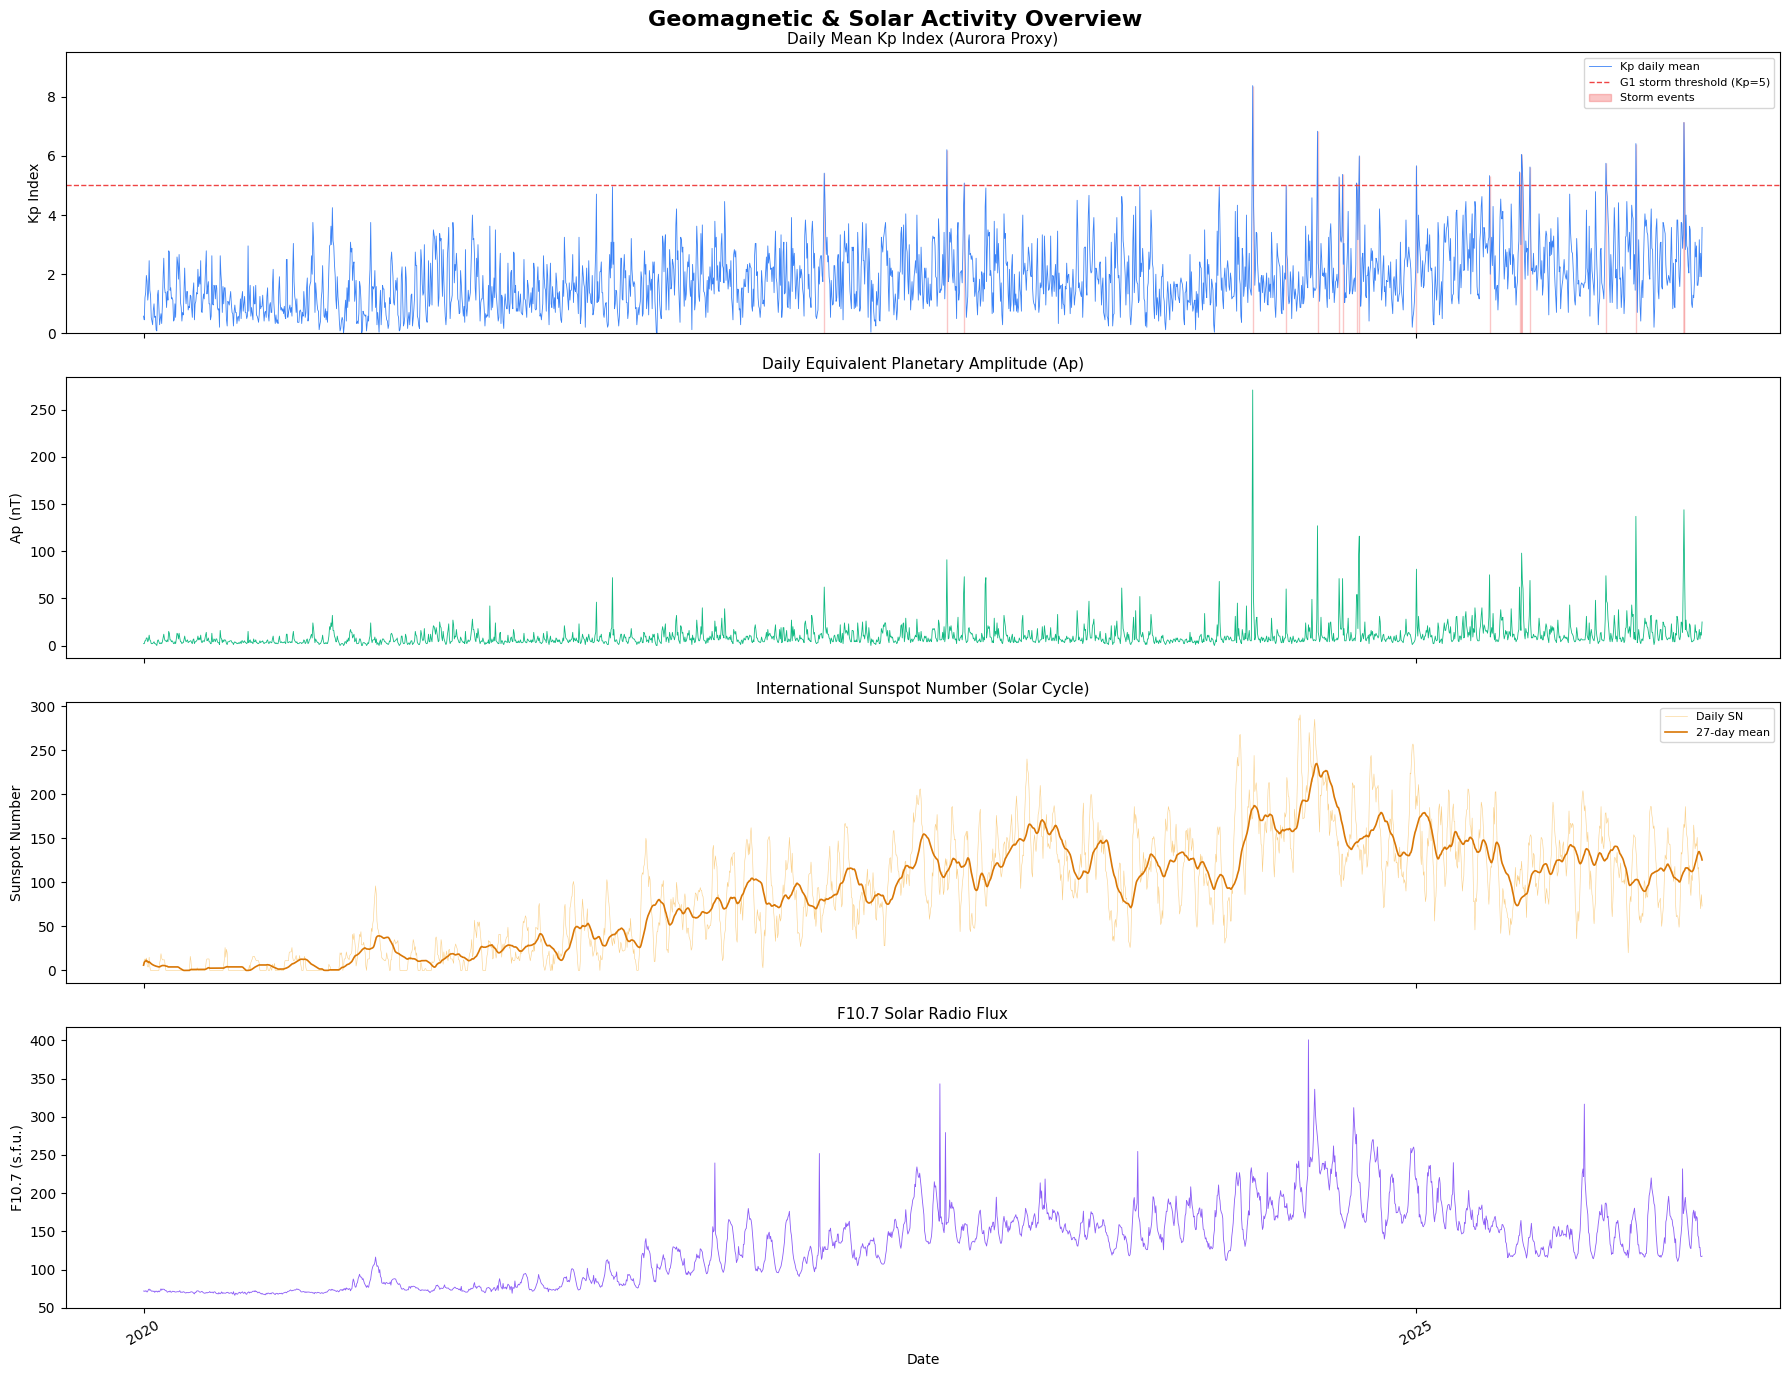


Total days in dataset   : 2,238
Aurora days (Kp ≥ 5)    : 207  (9.2%)
G2+ storm days (Kp ≥ 6) : 67
G3+ storm days (Kp ≥ 7) : 31


In [28]:
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('Geomagnetic & Solar Activity Overview', fontsize=16, fontweight='bold', y=0.98)

# Subsample to keep plot manageable for large datasets
plot_df = df[df['date'] >= '1970-01-01'].copy()

# 1 — Kp daily mean with storm threshold
ax = axes[0]
ax.plot(plot_df['date'], plot_df['Kp_mean'], lw=0.6, color='#3b82f6', label='Kp daily mean')
ax.axhline(5, color='#ef4444', lw=1, ls='--', label='G1 storm threshold (Kp=5)')
ax.fill_between(plot_df['date'], 0, plot_df['Kp_mean'],
                where=plot_df['Kp_mean'] >= 5, alpha=0.3, color='#ef4444', label='Storm events')
ax.set_ylabel('Kp Index'); ax.legend(fontsize=8); ax.set_ylim(0, 9.5)
ax.set_title('Daily Mean Kp Index (Aurora Proxy)', fontsize=11)

# 2 — Daily Ap
ax = axes[1]
ax.plot(plot_df['date'], plot_df['Ap'], lw=0.6, color='#10b981')
ax.set_ylabel('Ap (nT)'); ax.set_title('Daily Equivalent Planetary Amplitude (Ap)', fontsize=11)

# 3 — Sunspot number with 27-day rolling mean
ax = axes[2]
ax.plot(plot_df['date'], plot_df['SN'], lw=0.4, color='#f59e0b', alpha=0.5, label='Daily SN')
ax.plot(plot_df['date'], plot_df['SN_rolling27'], lw=1.2, color='#d97706', label='27-day mean')
ax.set_ylabel('Sunspot Number'); ax.legend(fontsize=8)
ax.set_title('International Sunspot Number (Solar Cycle)', fontsize=11)

# 4 — F10.7 Solar Flux
ax = axes[3]
mask_f107 = plot_df['F107obs'] > 0
ax.plot(plot_df.loc[mask_f107,'date'], plot_df.loc[mask_f107,'F107obs'], lw=0.6, color='#8b5cf6')
ax.set_ylabel('F10.7 (s.f.u.)'); ax.set_xlabel('Date')
ax.set_title('F10.7 Solar Radio Flux', fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Aurora event statistics
total_days   = len(df)
aurora_days  = df['aurora_flag'].sum()
print(f"\nTotal days in dataset   : {total_days:,}")
print(f"Aurora days (Kp ≥ 5)    : {int(aurora_days):,}  ({100*aurora_days/total_days:.1f}%)")
print(f"G2+ storm days (Kp ≥ 6) : {int((df['Kp_max']>=6).sum()):,}")
print(f"G3+ storm days (Kp ≥ 7) : {int((df['Kp_max']>=7).sum()):,}")

## Sequence Builder & Train/Val/Test Split

In [29]:
def create_sequences(X_data, y_data, lookback):
    """
    Create supervised (X, y) sequence pairs for LSTM training.
    X shape: (n_samples, lookback, n_features)
    y shape: (n_samples,)
    """
    X, y = [], []
    for i in range(lookback, len(X_data)):
        X.append(X_data[i - lookback: i])
        y.append(y_data[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# ── Scale features and target ──────────────────────────────────────────────────
feature_scaler = RobustScaler()   # robust to outliers (geomagnetic storms)
target_scaler  = MinMaxScaler(feature_range=(0, 1))

n = len(df)
n_test  = int(n * TEST_SPLIT)
n_val   = int(n * VAL_SPLIT)
n_train = n - n_test - n_val

print(f"Train: {n_train:,} days ({df['date'].iloc[0].date()} → {df['date'].iloc[n_train-1].date()})")
print(f"Val:   {n_val:,}   days")
print(f"Test:  {n_test:,}  days ({df['date'].iloc[-n_test].date()} → {df['date'].iloc[-1].date()})")

X_all = df[FEATURE_COLS_FULL].values
y_all = df[TARGET_COL].values.reshape(-1, 1)

# Fit scalers on train only
X_train_raw = feature_scaler.fit_transform(X_all[:n_train])
y_train_raw = target_scaler.fit_transform(y_all[:n_train]).ravel()

X_val_raw   = feature_scaler.transform(X_all[n_train:n_train+n_val])
y_val_raw   = target_scaler.transform(y_all[n_train:n_train+n_val]).ravel()

X_test_raw  = feature_scaler.transform(X_all[n_train+n_val:])
y_test_raw  = target_scaler.transform(y_all[n_train+n_val:]).ravel()

# For evaluation we also need the full test target in original scale
y_test_orig = y_all[n_train+n_val + LOOKBACK:].ravel()   # offset by LOOKBACK

# Build sequences
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK)
X_val,   y_val   = create_sequences(X_val_raw,   y_val_raw,   LOOKBACK)
X_test,  y_test  = create_sequences(X_test_raw,  y_test_raw,  LOOKBACK)

n_features = X_train.shape[2]
print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Features per timestep: {n_features}")

Train: 1,568 days (2020-01-01 → 2024-04-16)
Val:   335   days
Test:  335  days (2025-03-18 → 2026-02-15)

X_train: (1561, 7, 44)  y_train: (1561,)
X_val:   (328, 7, 44)    y_val:   (328,)
X_test:  (328, 7, 44)   y_test:  (328,)
Features per timestep: 44


## Model Definitions

In [30]:
# ── Shared callbacks ───────────────────────────────────────────────────────────
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0),
        ModelCheckpoint(str(OUTPUT_DATA / f'best_{name}.keras'), monitor='val_loss', save_best_only=True, verbose=0),
    ]


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — Deep Stacked LSTM
# ─────────────────────────────────────────────────────────────────────────────
def build_stacked_lstm(lookback, n_features):
    """
    4-layer stacked LSTM with residual-style skip connections,
    BatchNorm, and dropout.  Captures long-range temporal patterns.
    """
    model = Sequential([
        Input(shape=(lookback, n_features)),

        # Block 1
        LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.30),

        # Block 2
        LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.25),

        # Block 3
        LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.20),

        # Block 4 — bottleneck
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.15),

        # Dense head
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.10),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid'),   # output in [0,1] after MinMaxScaler
    ], name='Stacked_LSTM')

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='huber',        # robust to geomagnetic storm outliers
        metrics=['mae']
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — Bidirectional LSTM
# ─────────────────────────────────────────────────────────────────────────────
def build_bilstm(lookback, n_features):
    """
    3-layer BiLSTM — reads the sequence in both directions,
    capturing forward solar wind trends AND backward pattern context.
    """
    model = Sequential([
        Input(shape=(lookback, n_features)),

        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.30),

        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.25),

        Bidirectional(LSTM(64, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.20),

        Dense(64, activation='relu'),
        Dropout(0.10),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='BiLSTM')

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='huber',
        metrics=['mae']
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — CNN-LSTM (local feature extraction → temporal modelling)
# ─────────────────────────────────────────────────────────────────────────────
def build_cnn_lstm(lookback, n_features):
    """
    1-D CNN extracts local 3-hourly patterns (sub-storm onset features),
    then LSTM layers model the resulting temporal dependencies.
    """
    model = Sequential([
        Input(shape=(lookback, n_features)),

        # CNN feature extraction
        Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Temporal modelling
        LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(64, activation='relu'),
        Dropout(0.10),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='CNN_LSTM')

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='huber',
        metrics=['mae']
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4 — Attention-LSTM (Multi-Head Self-Attention + LSTM)
# ─────────────────────────────────────────────────────────────────────────────
def build_attention_lstm(lookback, n_features):
    """
    Multi-Head Attention helps the model focus on the most geomagnetically
    relevant timesteps (e.g., substorm onset, storm sudden commencement).
    """
    inputs = Input(shape=(lookback, n_features))

    # LSTM encoding
    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)

    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)

    # Multi-Head Attention
    attn_out  = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x         = Add()([x, attn_out])     # residual
    x         = LayerNormalization()(x)
    x         = Dropout(0.20)(x)

    # Second attention block
    attn_out2 = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x         = Add()([x, attn_out2])
    x         = LayerNormalization()(x)

    # Pool to vector
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.15)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='Attention_LSTM')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='huber',
        metrics=['mae']
    )
    return model


# Print summaries
for build_fn in [build_stacked_lstm, build_bilstm, build_cnn_lstm, build_attention_lstm]:
    m = build_fn(LOOKBACK, n_features)
    print(f"\n{'='*60}")
    print(f"  {m.name}  —  params: {m.count_params():,}")
    print('='*60)


  Stacked_LSTM  —  params: 136,385

  BiLSTM  —  params: 267,457

  CNN_LSTM  —  params: 104,513

  Attention_LSTM  —  params: 103,361


## Training

In [31]:
def train_model(build_fn, name, X_tr, y_tr, X_v, y_v):
    print(f"\n{'─'*60}")
    print(f"  Training: {name}")
    print(f"{'─'*60}")
    model = build_fn(LOOKBACK, n_features)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(name),
        verbose=1,
    )
    print(f"  Best val loss: {min(history.history['val_loss']):.5f}")
    return model, history


model_configs = [
    (build_stacked_lstm, 'Stacked LSTM'),
    (build_bilstm,       'BiLSTM'),
    (build_cnn_lstm,     'CNN-LSTM'),
    (build_attention_lstm, 'Attn-LSTM'),
]

trained_models   = {}
training_history = {}

for build_fn, name in model_configs:
    model, hist = train_model(build_fn, name, X_train, y_train, X_val, y_val)
    trained_models[name]   = model
    training_history[name] = hist

print("\n✅ All models trained.")


────────────────────────────────────────────────────────────
  Training: Stacked LSTM
────────────────────────────────────────────────────────────
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - loss: 0.0568 - mae: 0.1653 - val_loss: 0.0578 - val_mae: 0.1886 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0446 - mae: 0.1195 - val_loss: 0.0560 - val_mae: 0.1870 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0423 - mae: 0.1166 - val_loss: 0.0537 - val_mae: 0.1840 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0396 - mae: 0.1115 - val_loss: 0.0515 - val_mae: 0.1809 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0378 - mae: 0.1096 - val_loss: 0.0482 - val_mae: 0.1725 - learning_rate: 0.0010
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0360 - mae: 0.1074 - val_loss: 0.0458 - val_mae: 0.1677 - learning_rate: 0.0010
Epoch

## Training Curves

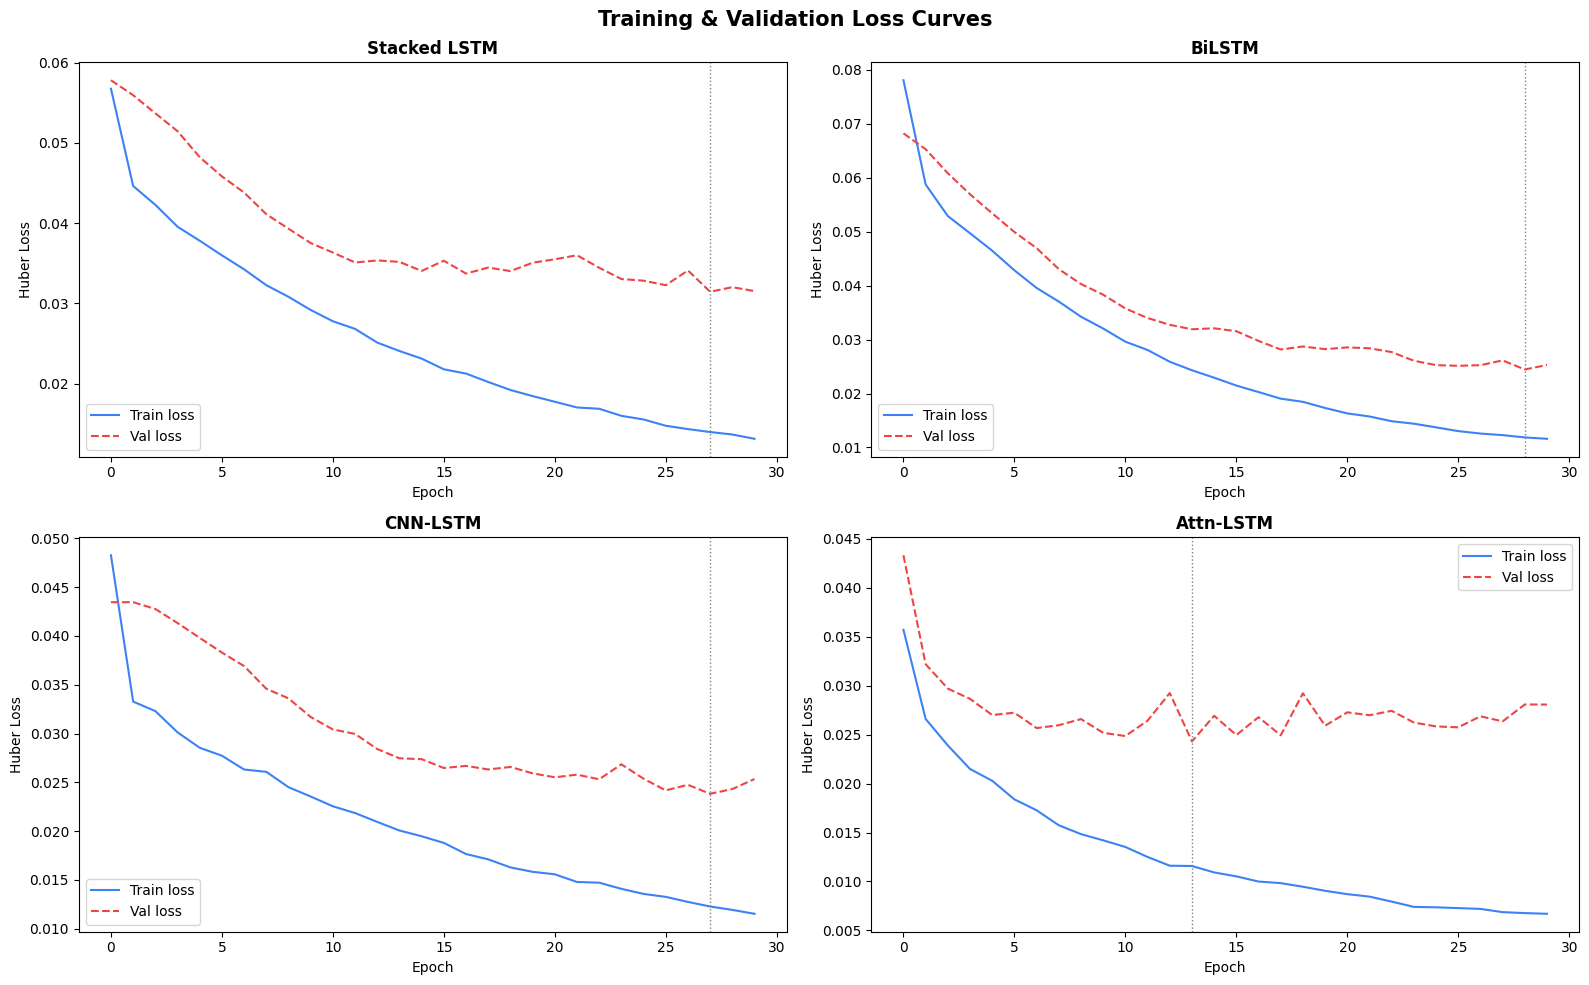

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training & Validation Loss Curves', fontsize=15, fontweight='bold')

for ax, (name, hist) in zip(axes.ravel(), training_history.items()):
    ax.plot(hist.history['loss'],     label='Train loss', lw=1.5, color='#3b82f6')
    ax.plot(hist.history['val_loss'], label='Val loss',   lw=1.5, color='#ef4444', ls='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend()
    best_ep = np.argmin(hist.history['val_loss'])
    ax.axvline(best_ep, color='gray', ls=':', lw=1, label=f'Best epoch {best_ep}')

plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [33]:
def evaluate_model(model, X_te, y_te_scaled, name):
    y_pred_scaled = model.predict(X_te, verbose=0).ravel()

    # Inverse-transform to original Kp scale
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    y_true = target_scaler.inverse_transform(y_te_scaled.reshape(-1,1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    # Aurora detection metrics
    true_aurora = (y_true >= AURORA_KP_THRESHOLD).astype(int)
    pred_aurora = (y_pred >= AURORA_KP_THRESHOLD).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    if true_aurora.sum() > 0:
        prec = precision_score(true_aurora, pred_aurora, zero_division=0)
        rec  = recall_score(true_aurora, pred_aurora, zero_division=0)
        f1   = f1_score(true_aurora, pred_aurora, zero_division=0)
    else:
        prec = rec = f1 = 0.0

    print(f"  {name:<18}  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}  "
          f"MAPE: {mape:.1f}%  |  Aurora Prec: {prec:.3f}  Rec: {rec:.3f}  F1: {f1:.3f}")

    return {'name': name, 'y_pred': y_pred, 'y_true': y_true,
            'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape,
            'precision': prec, 'recall': rec, 'f1': f1}


print("TEST SET METRICS")
print("=" * 110)
eval_results = {}
for name, model in trained_models.items():
    eval_results[name] = evaluate_model(model, X_test, y_test, name)

TEST SET METRICS
  Stacked LSTM        RMSE: 1.5659  MAE: 1.2209  R²: -0.8952  MAPE: 48.1%  |  Aurora Prec: 0.000  Rec: 0.000  F1: 0.000
  BiLSTM              RMSE: 1.2740  MAE: 0.9978  R²: -0.2546  MAPE: 41.8%  |  Aurora Prec: 0.000  Rec: 0.000  F1: 0.000
  CNN-LSTM            RMSE: 1.3098  MAE: 1.0343  R²: -0.3261  MAPE: 43.7%  |  Aurora Prec: 0.000  Rec: 0.000  F1: 0.000
  Attn-LSTM           RMSE: 1.3104  MAE: 1.0093  R²: -0.3273  MAPE: 44.9%  |  Aurora Prec: 0.000  Rec: 0.000  F1: 0.000


## Predictions vs Actuals

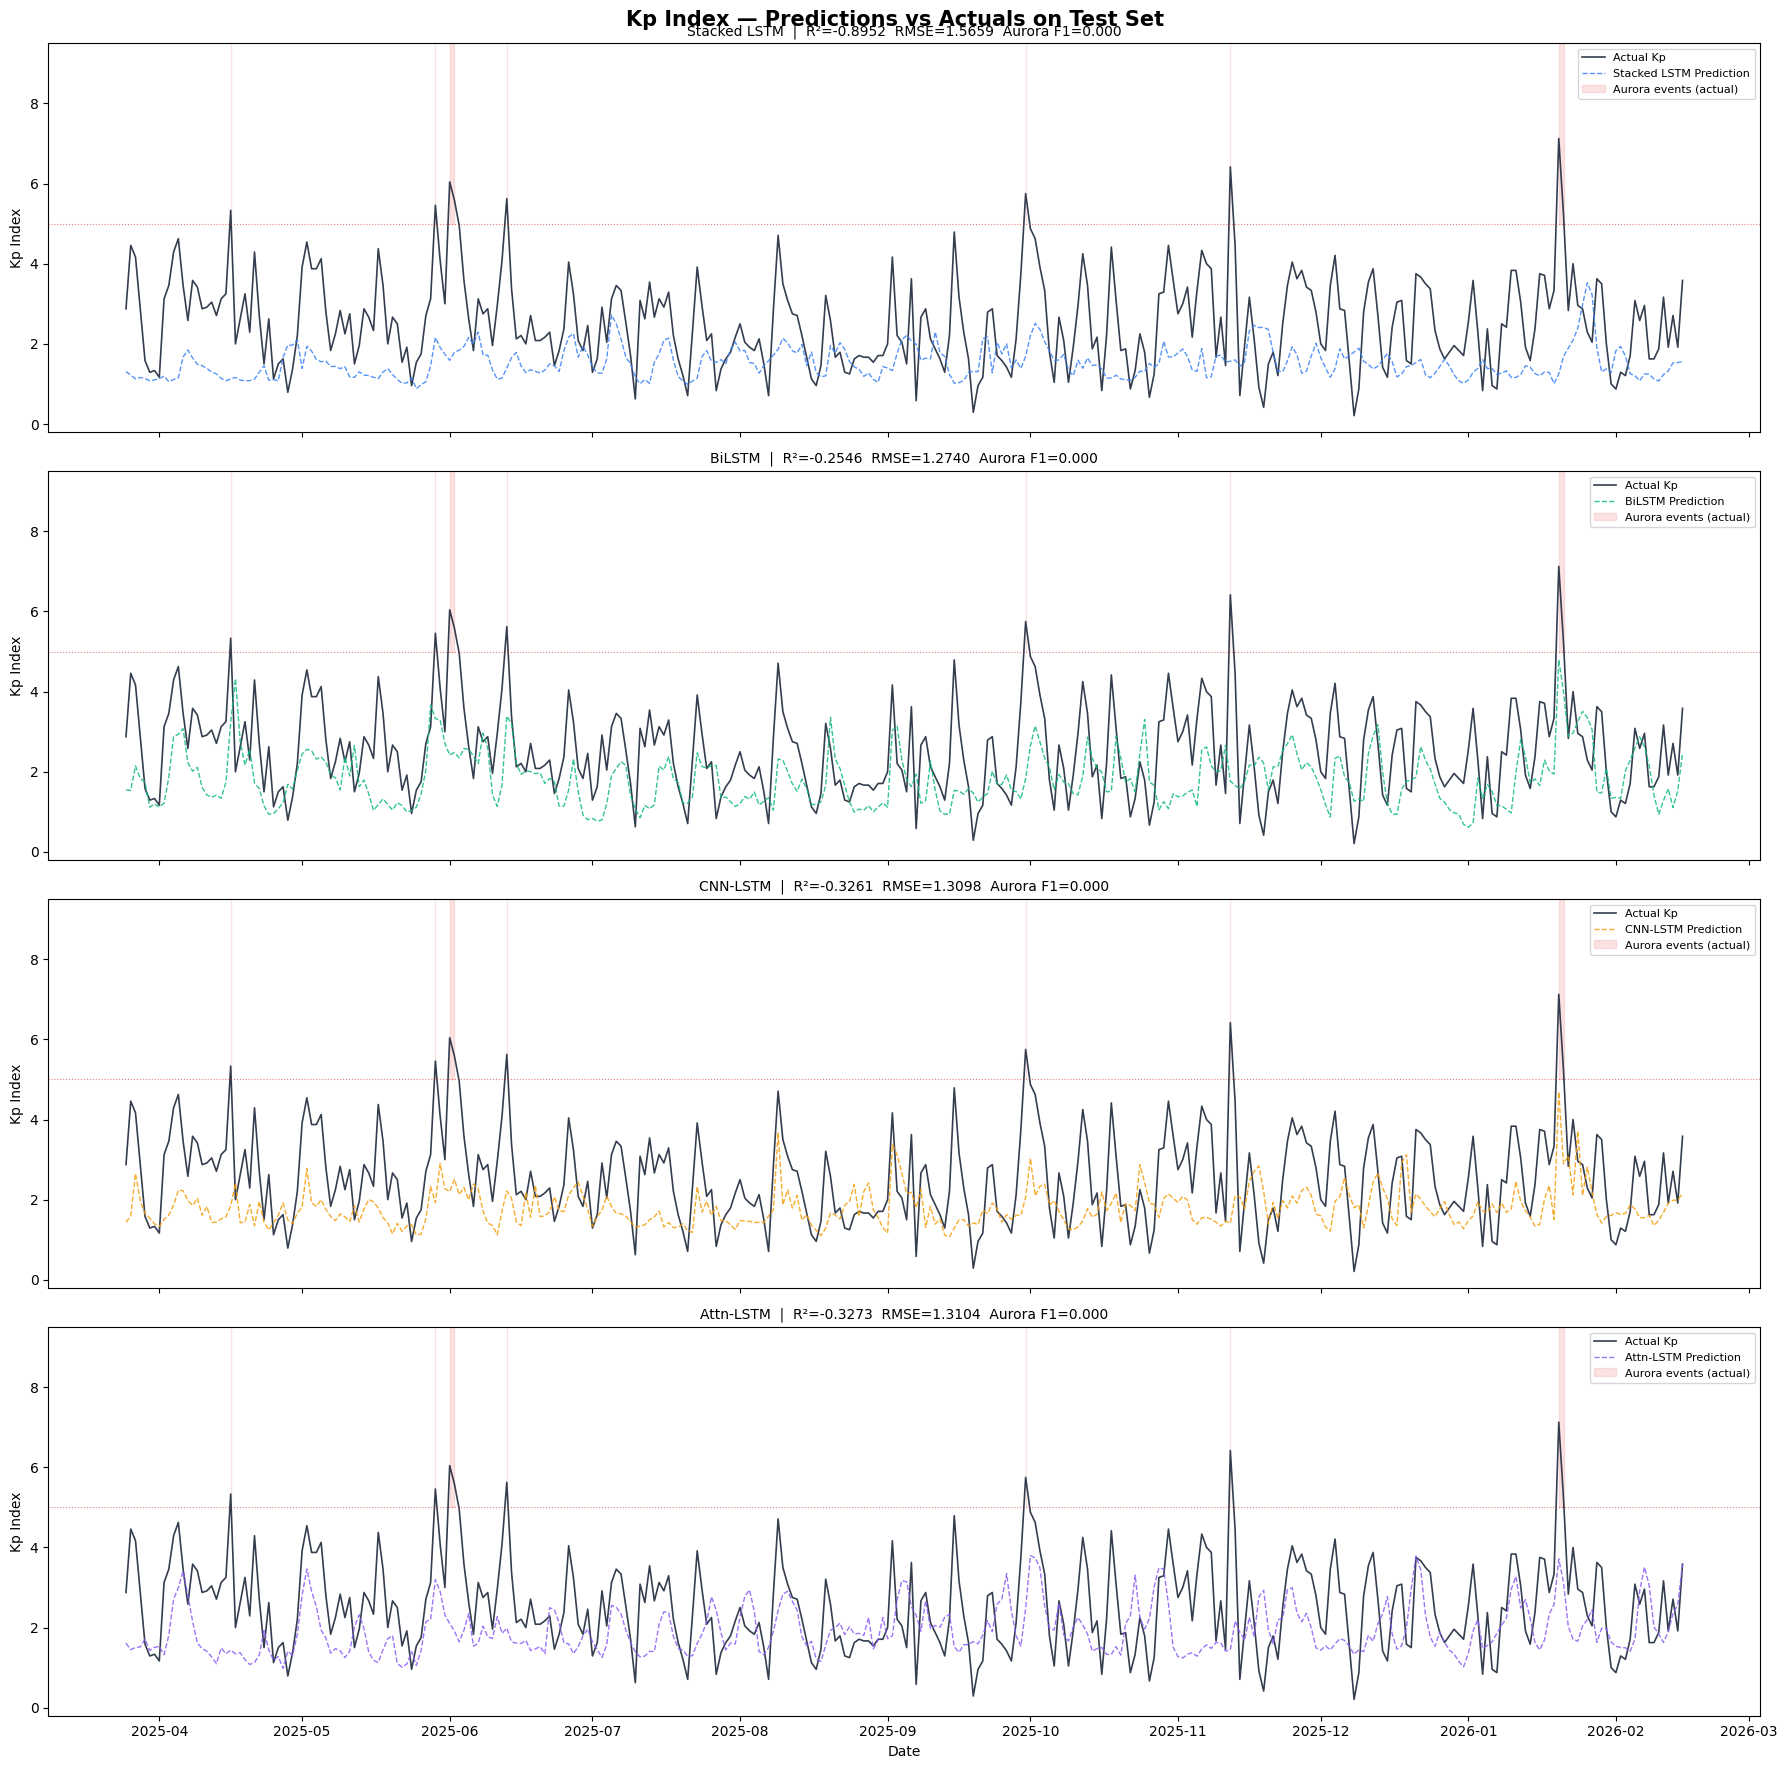

In [34]:
# Reconstruct test-set dates
test_start_idx = n_train + n_val + LOOKBACK
test_dates = df['date'].iloc[test_start_idx : test_start_idx + len(y_test)].values

fig, axes = plt.subplots(4, 1, figsize=(18, 18), sharex=True)
fig.suptitle('Kp Index — Predictions vs Actuals on Test Set', fontsize=15, fontweight='bold')

model_names_plot = list(eval_results.keys())
for ax, name in zip(axes, model_names_plot):
    res = eval_results[name]
    y_true = res['y_true']
    y_pred = res['y_pred']

    ax.plot(test_dates, y_true, lw=1.2, color=COLORS['Actual'], label='Actual Kp', alpha=0.9)
    ax.plot(test_dates, y_pred, lw=1.0, color=COLORS.get(name, '#6366f1'),
            label=f'{name} Prediction', alpha=0.85, ls='--')
    ax.axhline(AURORA_KP_THRESHOLD, color='#dc2626', lw=0.8, ls=':', alpha=0.6)
    ax.fill_between(test_dates, AURORA_KP_THRESHOLD, 9.5,
                    where=(y_true >= AURORA_KP_THRESHOLD),
                    alpha=0.15, color='#ef4444', label='Aurora events (actual)')
    ax.set_ylabel('Kp Index')
    ax.set_title(f"{name}  |  R²={res['r2']:.4f}  RMSE={res['rmse']:.4f}  "
                 f"Aurora F1={res['f1']:.3f}", fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(-0.2, 9.5)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_predictions_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison Dashboard

       Model   RMSE    MAE      R²  MAPE (%)  Aurora Prec  Aurora Rec  Aurora F1
      BiLSTM 1.2740 0.9978 -0.2546 41.799999          0.0         0.0        0.0
    CNN-LSTM 1.3098 1.0343 -0.3261 43.730000          0.0         0.0        0.0
   Attn-LSTM 1.3104 1.0093 -0.3273 44.939999          0.0         0.0        0.0
Stacked LSTM 1.5659 1.2209 -0.8952 48.099998          0.0         0.0        0.0


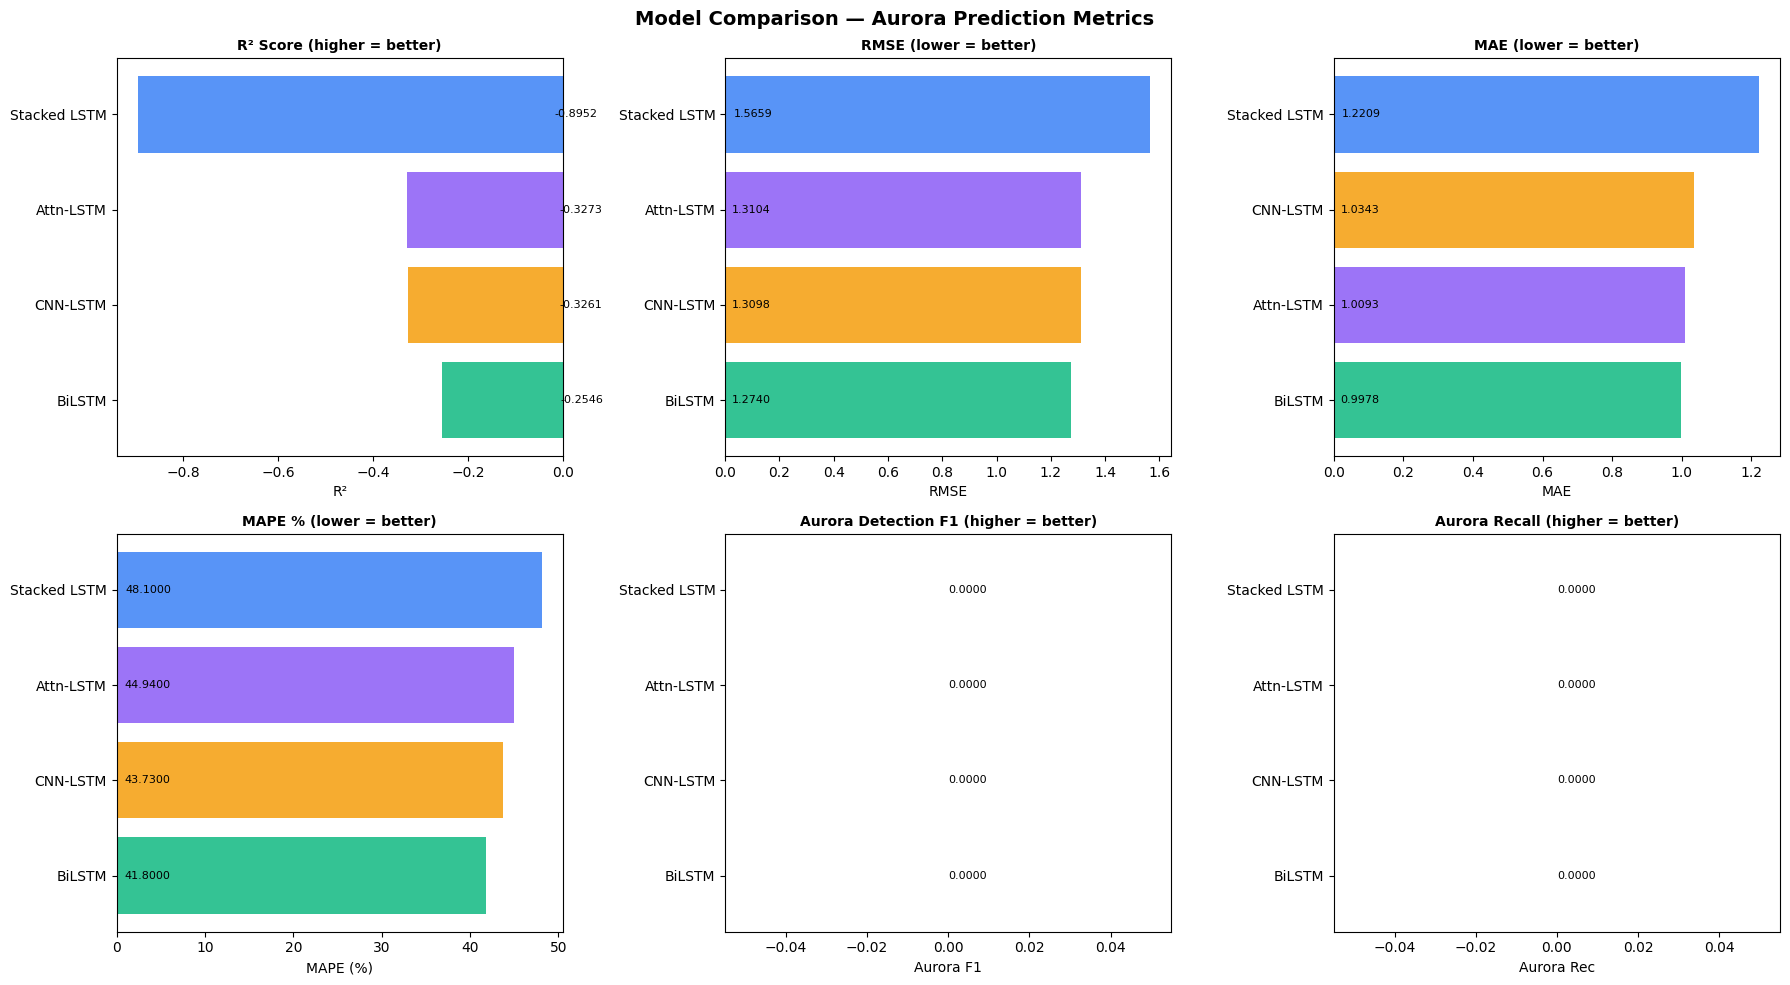

In [35]:
# ── Comparison table ───────────────────────────────────────────────────────────
rows = []
for name, res in eval_results.items():
    rows.append({
        'Model':        name,
        'RMSE':         round(res['rmse'], 4),
        'MAE':          round(res['mae'], 4),
        'R²':           round(res['r2'], 4),
        'MAPE (%)':     round(res['mape'], 2),
        'Aurora Prec':  round(res['precision'], 3),
        'Aurora Rec':   round(res['recall'], 3),
        'Aurora F1':    round(res['f1'], 3),
    })
comp_df = pd.DataFrame(rows).sort_values('R²', ascending=False)
print(comp_df.to_string(index=False))

# ── Metric bar charts ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison — Aurora Prediction Metrics', fontsize=14, fontweight='bold')

palette = [COLORS.get(n, '#6366f1') for n in comp_df['Model']]

metrics = [
    ('R²',        True,  'R² Score (higher = better)'),
    ('RMSE',      False, 'RMSE (lower = better)'),
    ('MAE',       False, 'MAE (lower = better)'),
    ('MAPE (%)',  False, 'MAPE % (lower = better)'),
    ('Aurora F1', True,  'Aurora Detection F1 (higher = better)'),
    ('Aurora Rec',True,  'Aurora Recall (higher = better)'),
]

for ax, (metric, higher_better, title) in zip(axes.ravel(), metrics):
    sorted_df = comp_df.sort_values(metric, ascending=not higher_better)
    ax.barh(sorted_df['Model'], sorted_df[metric],
            color=[COLORS.get(n, '#6366f1') for n in sorted_df['Model']], alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(metric)
    for i, (_, row) in enumerate(sorted_df.iterrows()):
        ax.text(row[metric] * 0.02, i, f"{row[metric]:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 30-Day Aurora Forecast

Generating 30-day forecasts...
  Stacked LSTM      : mean=1.69  max=2.06  aurora_days=0
  BiLSTM            : mean=1.66  max=1.93  aurora_days=0
  CNN-LSTM          : mean=2.37  max=2.85  aurora_days=0
  Attn-LSTM         : mean=1.75  max=3.29  aurora_days=0


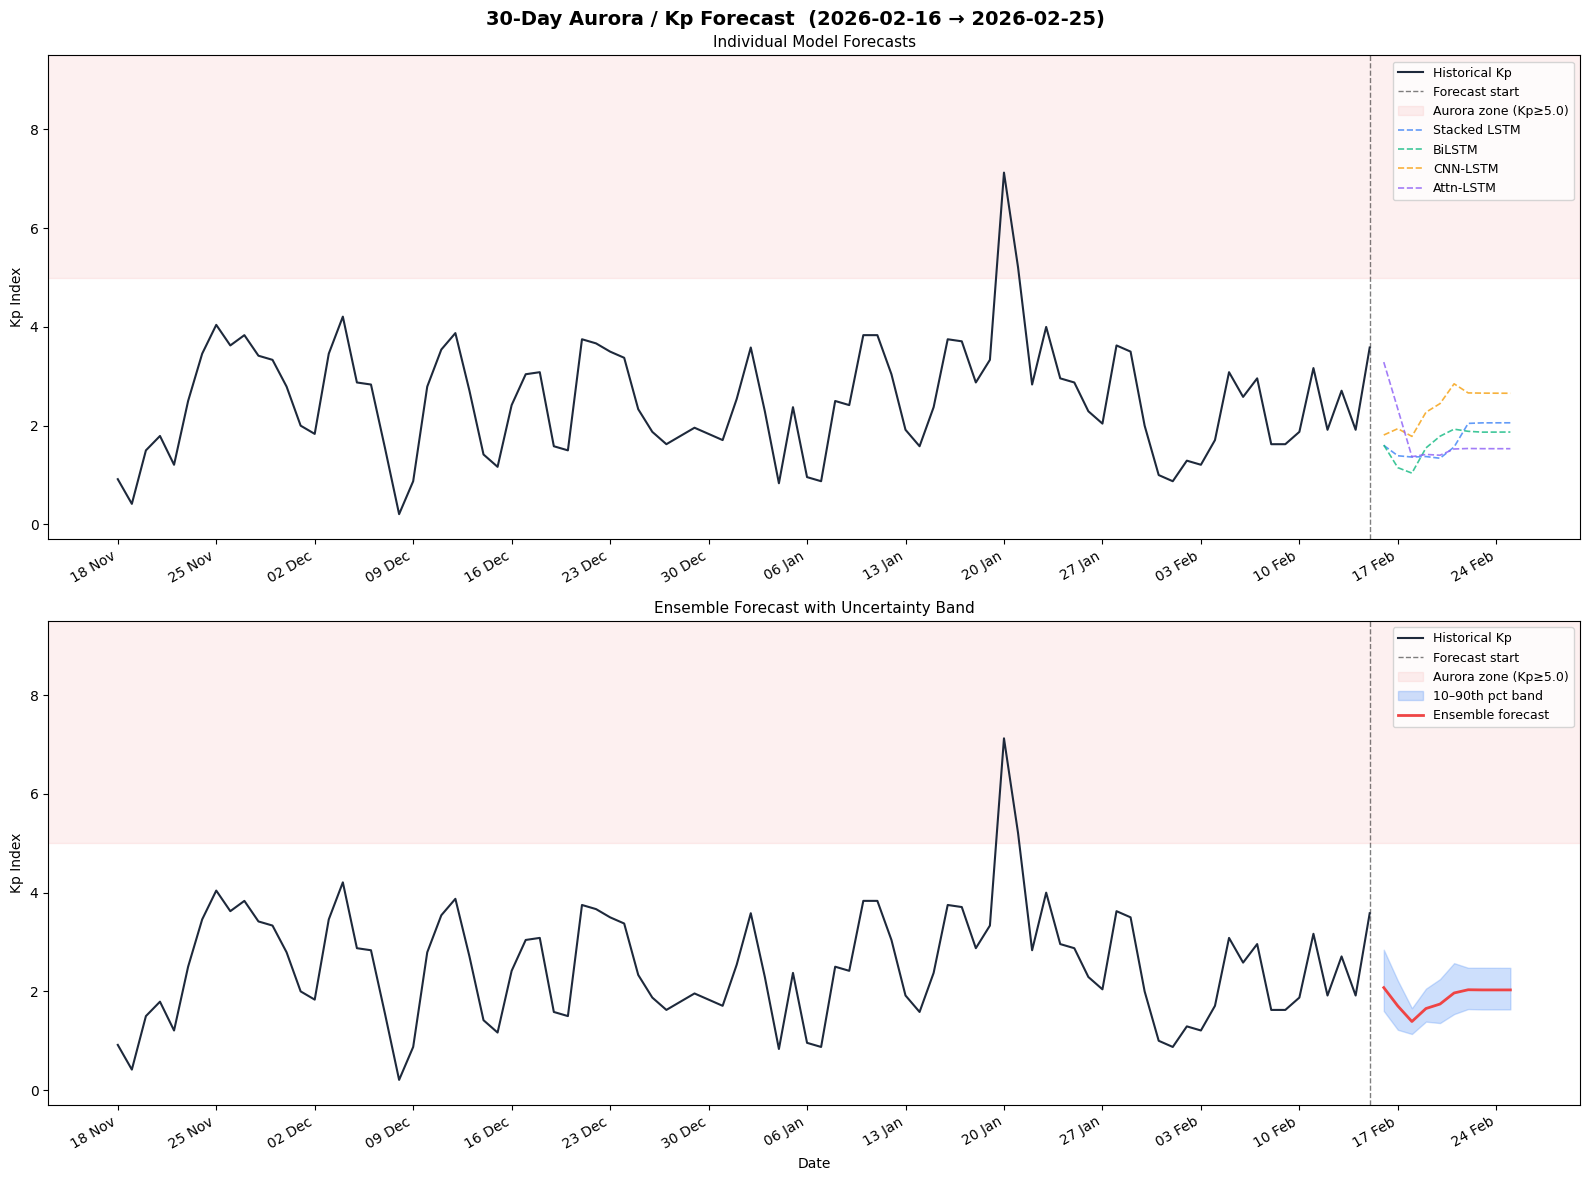

In [36]:
def recursive_forecast(model, last_sequence, steps, feature_scaler, target_scaler, df, all_features):
    """
    Auto-regressive multi-step forecast.
    For each step, use the prediction to update the target-related features
    and shift the window forward by one day.
    """
    seq = last_sequence.copy()   # shape: (lookback, n_features)
    forecasts = []

    # Index of TARGET_COL (Kp_mean) in the feature list
    target_idx = all_features.index(TARGET_COL) if TARGET_COL in all_features else None
    ap_idx     = all_features.index('Ap') if 'Ap' in all_features else None

    for step in range(steps):
        # Predict
        x_input = seq[np.newaxis, :, :]       # (1, lookback, features)
        y_scaled = model.predict(x_input, verbose=0)[0, 0]
        y_kp = float(target_scaler.inverse_transform([[y_scaled]])[0, 0])
        forecasts.append(y_kp)

        # Roll window: drop oldest timestep, append new row
        new_row = seq[-1].copy()     # copy last timestep as baseline
        if target_idx is not None:
            # Update Kp_mean in the new row with the prediction (scaled)
            new_row[target_idx] = y_scaled
        seq = np.vstack([seq[1:], new_row])

    return np.array(forecasts)


# Last LOOKBACK days of scaled test data as seed
seed_sequence = X_test_raw[-LOOKBACK:]  # (lookback, features)

last_date = df['date'].iloc[-1]
forecast_dates = pd.date_range(last_date + timedelta(days=1), periods=FORECAST_DAYS, freq='D')

forecasts = {}
print("Generating 30-day forecasts...")
for name, model in trained_models.items():
    fc = recursive_forecast(model, seed_sequence, FORECAST_DAYS,
                            feature_scaler, target_scaler, df, FEATURE_COLS_FULL)
    fc = np.clip(fc, 0, 9)   # Kp is bounded [0, 9]
    forecasts[name] = fc
    print(f"  {name:<18}: mean={fc.mean():.2f}  max={fc.max():.2f}  "
          f"aurora_days={int((fc >= AURORA_KP_THRESHOLD).sum())}")

# ── Ensemble forecast (mean of all models) ────────────────────────────────────
ensemble_fc = np.mean(list(forecasts.values()), axis=0)
forecasts['Ensemble'] = ensemble_fc

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(f'30-Day Aurora / Kp Forecast  ({forecast_dates[0].date()} → {forecast_dates[-1].date()})',
             fontsize=14, fontweight='bold')

# Show last 90 days of actual data as context
context_n    = 90
context_idx  = max(0, len(df) - context_n)
context_dates = df['date'].iloc[context_idx:].values
context_kp    = df[TARGET_COL].iloc[context_idx:].values

for ax in axes:
    ax.plot(context_dates, context_kp, color=COLORS['Actual'], lw=1.5, label='Historical Kp', zorder=5)
    ax.axvline(last_date, color='black', ls='--', lw=1, alpha=0.5, label='Forecast start')
    ax.axhspan(AURORA_KP_THRESHOLD, 9.5, alpha=0.08, color='#ef4444', label=f'Aurora zone (Kp≥{AURORA_KP_THRESHOLD})')

# Ax1 — all individual model forecasts
for name, fc in forecasts.items():
    if name == 'Ensemble': continue
    color = COLORS.get(name, '#6366f1')
    axes[0].plot(forecast_dates, fc, color=color, lw=1.2, ls='--', label=name, alpha=0.8)
axes[0].set_title('Individual Model Forecasts', fontsize=11)
axes[0].legend(fontsize=9); axes[0].set_ylabel('Kp Index'); axes[0].set_ylim(-0.3, 9.5)

# Ax2 — ensemble with confidence band
all_fc_arr = np.array([forecasts[n] for n in trained_models])
fc_lower   = np.percentile(all_fc_arr, 10, axis=0)
fc_upper   = np.percentile(all_fc_arr, 90, axis=0)
axes[1].fill_between(forecast_dates, fc_lower, fc_upper, alpha=0.25, color='#3b82f6', label='10–90th pct band')
axes[1].plot(forecast_dates, ensemble_fc, color=COLORS['Forecast'], lw=2, label='Ensemble forecast')
axes[1].set_title('Ensemble Forecast with Uncertainty Band', fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_ylabel('Kp Index'); axes[1].set_ylim(-0.3, 9.5)
axes[1].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Aurora Alert Calendar


30-DAY AURORA FORECAST CALENDAR
      Date  Kp_Ensemble  Kp_Lower_10  Kp_Upper_90  Aurora_Prob (%) Storm_Level
2026-02-16         2.08         1.60         2.84              0.0       Quiet
2026-02-17         1.70         1.22         2.22              0.0       Quiet
2026-02-18         1.39         1.14         1.66              0.0       Quiet
2026-02-19         1.65         1.39         2.06              0.0       Quiet
2026-02-20         1.74         1.36         2.25              0.0       Quiet
2026-02-21         1.97         1.54         2.57              0.0       Quiet
2026-02-22         2.03         1.64         2.48              0.0       Quiet
2026-02-23         2.03         1.64         2.48              0.0       Quiet
2026-02-24         2.03         1.63         2.48              0.0       Quiet
2026-02-25         2.03         1.64         2.48              0.0       Quiet


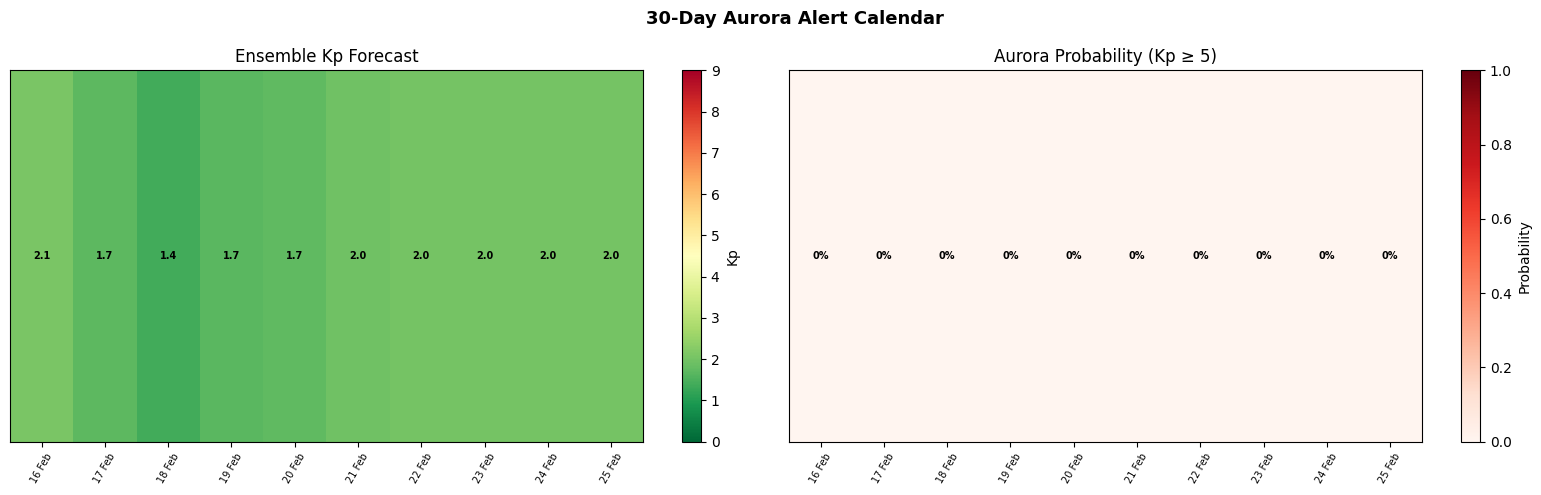

In [37]:
# ── Daily aurora probability from ensemble ─────────────────────────────────────
# Fraction of models predicting Kp ≥ 5 on each forecast day
model_array   = np.array([forecasts[n] for n in trained_models])
aurora_prob   = (model_array >= AURORA_KP_THRESHOLD).mean(axis=0)

alert_df = pd.DataFrame({
    'Date':            forecast_dates,
    'Kp_Ensemble':     np.round(ensemble_fc, 2),
    'Kp_Lower_10':     np.round(fc_lower, 2),
    'Kp_Upper_90':     np.round(fc_upper, 2),
    'Aurora_Prob (%)': np.round(aurora_prob * 100, 1),
    'Storm_Level':     [  'G3+' if k >= 7
                           else 'G2'  if k >= 6
                           else 'G1'  if k >= 5
                           else 'Active' if k >= 4
                           else 'Quiet'
                        for k in ensemble_fc ]
})

print("\n30-DAY AURORA FORECAST CALENDAR")
print("=" * 75)
print(alert_df.to_string(index=False))

# ── Calendar heatmap ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('30-Day Aurora Alert Calendar', fontsize=13, fontweight='bold')

# Kp heatmap
kp_vals  = ensemble_fc.reshape(1, -1)
im1 = axes[0].imshow(kp_vals, cmap='RdYlGn_r', vmin=0, vmax=9, aspect='auto')
axes[0].set_xticks(range(FORECAST_DAYS))
axes[0].set_xticklabels([d.strftime('%d %b') for d in forecast_dates], rotation=60, fontsize=7)
axes[0].set_yticks([])
axes[0].set_title('Ensemble Kp Forecast')
for j, kp in enumerate(ensemble_fc):
    axes[0].text(j, 0, f"{kp:.1f}", ha='center', va='center', fontsize=7,
                 color='white' if kp > 4 else 'black', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Kp')

# Aurora probability heatmap
prob_vals = aurora_prob.reshape(1, -1)
im2 = axes[1].imshow(prob_vals, cmap='Reds', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(FORECAST_DAYS))
axes[1].set_xticklabels([d.strftime('%d %b') for d in forecast_dates], rotation=60, fontsize=7)
axes[1].set_yticks([])
axes[1].set_title('Aurora Probability (Kp ≥ 5)')
for j, p in enumerate(aurora_prob):
    axes[1].text(j, 0, f"{p*100:.0f}%", ha='center', va='center', fontsize=7,
                 color='white' if p > 0.5 else 'black', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_alert_calendar.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Gradient-Based)

Computing feature importance for: BiLSTM


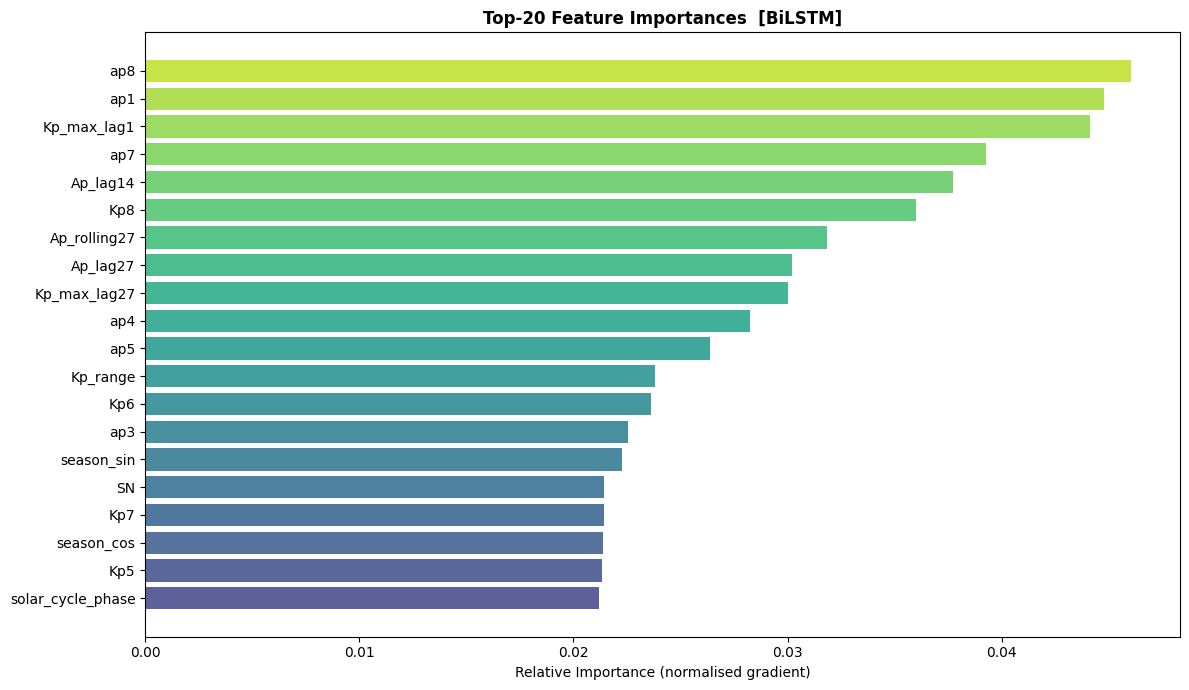

In [38]:
def gradient_feature_importance(model, X_sample, n_features, feature_names):
    """
    Compute input-gradient saliency: how much does each feature
    contribute to the prediction on average?
    """
    X_tensor = tf.constant(X_sample[:200], dtype=tf.float32)  # use 200 samples
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = model(X_tensor, training=False)
    grads = tape.gradient(preds, X_tensor)   # (200, lookback, features)
    importance = np.abs(grads.numpy()).mean(axis=(0, 1))   # average over samples & time
    importance /= importance.sum()   # normalise
    return importance


# Use the best model (highest R²)
best_model_name = max(eval_results, key=lambda k: eval_results[k]['r2'])
best_model = trained_models[best_model_name]
print(f"Computing feature importance for: {best_model_name}")

importance = gradient_feature_importance(best_model, X_test, n_features, FEATURE_COLS_FULL)

# Plot top-20 features
top_n = min(20, len(FEATURE_COLS_FULL))
top_idx = np.argsort(importance)[-top_n:][::-1]
top_names = [FEATURE_COLS_FULL[i] for i in top_idx]
top_vals  = importance[top_idx]

fig, ax = plt.subplots(figsize=(12, 7))
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
ax.barh(top_names[::-1], top_vals[::-1], color=colors_fi, alpha=0.85)
ax.set_xlabel('Relative Importance (normalised gradient)')
ax.set_title(f'Top-{top_n} Feature Importances  [{best_model_name}]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / 'aurora_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [39]:
import joblib

# Save scalers
joblib.dump(feature_scaler, OUTPUT_DATA / 'aurora_feature_scaler.pkl')
joblib.dump(target_scaler,  OUTPUT_DATA / 'aurora_target_scaler.pkl')
print("Scalers saved.")

# Save each trained model
for name, model in trained_models.items():
    fname = OUTPUT_DATA / f"aurora_model_{name.replace(' ', '_').replace('-', '_')}.keras"
    model.save(str(fname))
    print(f"Model saved: {fname}")

# Save forecast CSV
alert_df.to_csv(OUTPUT_DATA / 'aurora_30day_forecast.csv', index=False)
print("Forecast CSV saved: aurora_30day_forecast.csv")

# Save metrics CSV
comp_df.to_csv(OUTPUT_DATA / 'aurora_model_metrics.csv', index=False)
print("Metrics CSV saved: aurora_model_metrics.csv")

print("\n✅ All outputs saved successfully.")

Scalers saved.
Model saved: /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/data/aurora_model_Stacked_LSTM.keras
Model saved: /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/data/aurora_model_BiLSTM.keras
Model saved: /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/data/aurora_model_CNN_LSTM.keras
Model saved: /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/kp outputs/data/aurora_model_Attn_LSTM.keras
Forecast CSV saved: aurora_30day_forecast.csv
Metrics CSV saved: aurora_model_metrics.csv

✅ All outputs saved successfully.
